# IOH Benchmark, Behaviour Metrics & Elo Rating

Generates IOH data for the **best algorithm** from each of the three experiments used in
`Final-Comparison-Visualization`, then computes:

- **ECDF / AOCC** â€“ empirical cumulative distribution and area-over-convergence-curve
- **Behaviour Metrics** â€“ per-run exploration/exploitation profile
- **Elo Rating** â€“ tournament-style ranking across algorithms

**Experiments (Methods)**:
| Method | Experiment Dir |
|--------|----------------|
| `EoH` | `../results/EoH` |
| `Baseline-LLaMEA` | `../results/CROSSOVER-ABLATION/baseline-LLAMEA` |
| `GA-LLAMEA-8-INIT-100` | `../results/GA-LLAMEA-8-INIT-100` |

**Benchmark**: MA_BBOB, dim=5, budget=10â€¯000, instances 100â€“149, 5 repetitions each.

## 1. Setup

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import parallel_coordinates
from tqdm.std import tqdm

import ioh
from ioh import logger as ioh_logger
import iohinspector
import polars as pl

from iohblade.loggers import ExperimentLogger
from iohblade.behaviour_metrics import compute_behavior_metrics
from iohblade.utils import budget_logger
from iohblade import OverBudgetException

plt.rcParams.update({
    'figure.figsize': (12, 8),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
sns.set_palette('colorblind')
print('All imports successful.')

c:\Users\Kukoy\Documents\Experiment-GA\WORKING-GA-LLAMEA\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful.


## 2. Load Experiment Data

In [3]:
EXPERIMENT_DIRS = [
    '../results/EoH',
    '../results/CROSSOVER-ABLATION/baseline-LLAMEA',
    '../results/GA-LLAMEA-8-INIT-100',
]

# Where to write generated IOH data (one sub-folder per method)
IOH_OUTPUT_DIR = '../results/ioh-best'

# MA_BBOB configuration files (shipped with iohblade)
import iohblade as _iohblade
MABBOB_DIR = os.path.join(os.path.dirname(_iohblade.__file__), 'problems', 'mabbob')

weights  = pd.read_csv(os.path.join(MABBOB_DIR, 'weights.csv'),  index_col=0)
iids_df  = pd.read_csv(os.path.join(MABBOB_DIR, 'iids.csv'),     index_col=0)
opt_locs = pd.read_csv(os.path.join(MABBOB_DIR, 'opt_locs.csv'), index_col=0)
print(f'MA_BBOB data loaded from: {MABBOB_DIR}')
print(f'weights={weights.shape}, iids={iids_df.shape}, opt_locs={opt_locs.shape}')

MA_BBOB data loaded from: c:\Users\Kukoy\Documents\Experiment-GA\WORKING-GA-LLAMEA\venv\Lib\site-packages\iohblade\problems\mabbob
weights=(1000, 24), iids=(1000, 24), opt_locs=(1000, 20)


In [4]:
exp_logger = ExperimentLogger(EXPERIMENT_DIRS[0], True)
for extra_dir in EXPERIMENT_DIRS[1:]:
    exp_logger.add_read_dir(extra_dir)

methods, problems = exp_logger.get_methods_problems()
print(f'Methods ({len(methods)}): {sorted(methods)}')
print(f'Problems ({len(problems)}): {problems}')

Methods (3): ['Baseline-LLaMEA', 'EoH', 'GA-LLAMEA-8-INIT-100']
Problems (1): ['MA_BBOB']


## 3. Identify Best Algorithm Per Method

In [5]:
data = exp_logger.get_problem_data('MA_BBOB')
data.replace([-np.inf], 0, inplace=True)
data.fillna(0, inplace=True)

best_rows = data.loc[data.groupby('method_name')['fitness'].idxmax()].copy()
print('Best algorithms per method:')
print(best_rows[['method_name', 'name', 'fitness', 'seed']].to_string(index=False))

Best algorithms per method:
         method_name                                                                  name  fitness  seed
     Baseline-LLaMEA DifferentialEvolutionWithDynamicPBestPoolAndHybridRejuvenationArchive 0.856636     3
                 EoH                                             SuccessWeightedAdaptiveDE 0.837349     0
GA-LLAMEA-8-INIT-100                              AdaptiveSynergisticDifferentialEvolution 0.864023     4


## 4. Generate IOH Benchmark Data

Evaluates each best algorithm on MA_BBOB instances 100â€“149 (dim=5, budget=10â€¯000, 5 reps).  
Results are written to `../results/ioh-best/{method_name}/`.  
**Skip if the folder already exists.**

In [6]:
os.makedirs(IOH_OUTPUT_DIR, exist_ok=True)

for _, row in best_rows.iterrows():
    method_name    = row['method_name']
    algorithm_name = row['name']
    alg_code       = row['code']
    out_dir        = os.path.join(IOH_OUTPUT_DIR, method_name)

    if os.path.isdir(out_dir):
        print(f'[SKIP] {method_name} â€” IOH data already exists at {out_dir}')
        continue

    print(f'\nBenchmarking [{method_name}] â†’ {algorithm_name}')

    dim    = 5
    budget = 2000 * dim  # 10 000

    analyzer = ioh_logger.Analyzer(
        triggers=[ioh_logger.trigger.ALWAYS],
        folder_name=out_dir,
        algorithm_name=method_name,
        store_positions=True,
    )
    bl  = budget_logger(budget=budget)
    l1  = ioh_logger.Combine([bl, analyzer])

    for iid in tqdm(range(100, 150), desc=method_name):
        problem = ioh.problem.ManyAffine(
            xopt=np.array(opt_locs.iloc[iid])[:dim],
            weights=np.array(weights.iloc[iid]),
            instances=np.array(iids_df.iloc[iid], dtype=int),
            n_variables=dim,
        )
        problem.set_id(100)
        problem.set_instance(iid)
        problem.attach_logger(l1)

        for rep in range(5):
            np.random.seed(rep)
            try:
                safe_globals = {'np': np}
                local_env    = {}
                exec(alg_code, safe_globals, local_env)
                algorithm = local_env[algorithm_name](budget=budget, dim=dim)
                algorithm(problem)
            except OverBudgetException:
                pass
            except Exception:
                pass
            problem.reset()

    print(f'  â†’ Saved to {out_dir}')

print('\nIOH data generation complete.')

[SKIP] Baseline-LLaMEA â€” IOH data already exists at ../results/ioh-best\Baseline-LLaMEA
[SKIP] EoH â€” IOH data already exists at ../results/ioh-best\EoH
[SKIP] GA-LLAMEA-8-INIT-100 â€” IOH data already exists at ../results/ioh-best\GA-LLAMEA-8-INIT-100

IOH data generation complete.


## 5. Load IOH Data & ECDF / AOCC

In [7]:
manager = iohinspector.DataManager()
for method in sorted(methods):
    d = os.path.join(IOH_OUTPUT_DIR, method)
    if os.path.isdir(d):
        manager.add_folder(d)
        print(f'  Loaded: {d}')
    else:
        print(f'  [MISSING] {d}')

df_ioh = manager.load(monotonic=True, include_meta_data=True)
print(f'\nTotal rows (monotonic): {len(df_ioh)}')
print(f'Algorithms : {df_ioh["algorithm_name"].unique().to_list()}')
print(f'Dimensions : {df_ioh["dimension"].unique().to_list()}')

  Loaded: ../results/ioh-best\Baseline-LLaMEA
  Loaded: ../results/ioh-best\EoH
  Loaded: ../results/ioh-best\GA-LLAMEA-8-INIT-100

Total rows (monotonic): 85473
Algorithms : ['GA-LLAMEA-8-INIT-100', 'Baseline-LLaMEA', 'EoH']
Dimensions : [5]


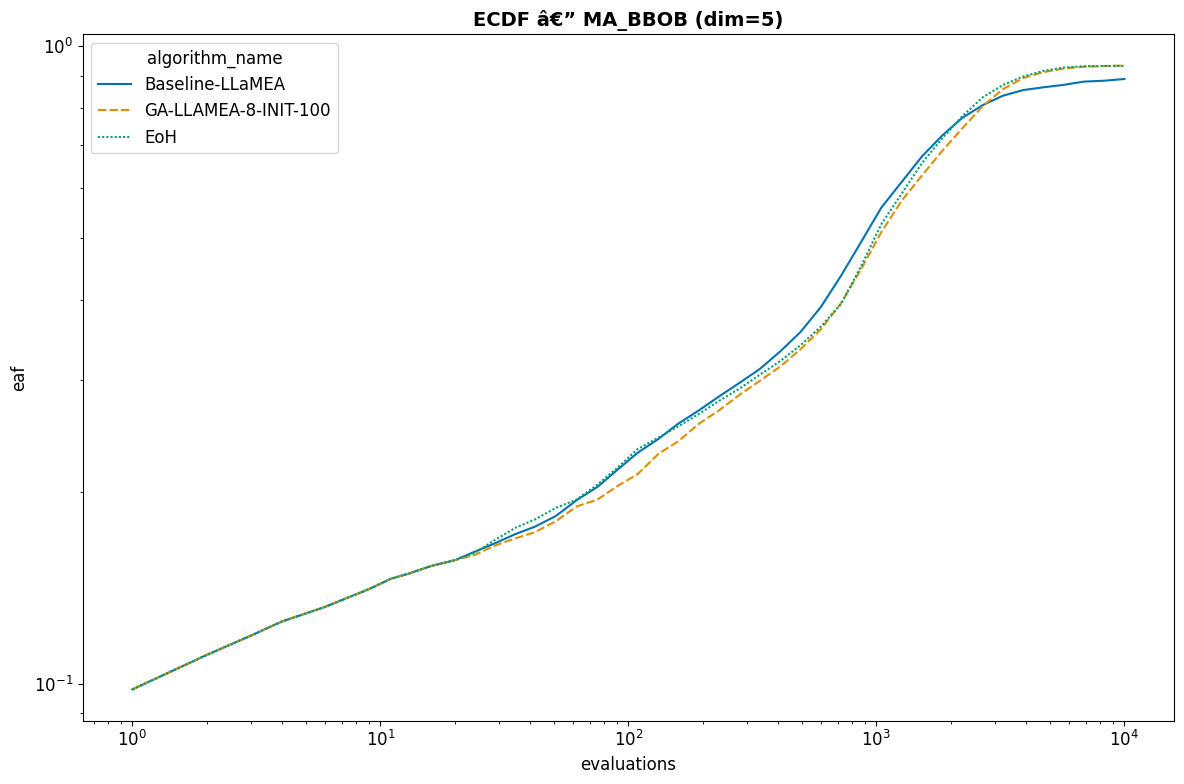

In [8]:
# FIX: plot_ecdf creates its own fig/ax; passing ax= triggers an UnboundLocalError
#      in the library. Use the returned ax to customise instead.
ax, _ = iohinspector.plot_ecdf(
    df_ioh.filter(pl.col('dimension') == 5),
    f_max=100, f_min=1e-8, scale_eval_log=True,
)
ax.figure.set_size_inches(12, 8)
ax.set_title('ECDF â€” MA_BBOB (dim=5)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# AOCC table
df_eaf = iohinspector.transform_fval(df_ioh, 1e-8, 1e2)
aocc   = iohinspector.get_aocc(
    df_eaf.filter(pl.col('dimension') == 5),
    10000,
    free_vars=['algorithm_name'],
)
print('AOCC per algorithm (dim=5):')
print(aocc)

AOCC per algorithm (dim=5):
         algorithm_name      AOCC
0  GA-LLAMEA-8-INIT-100  0.815701
1                   EoH  0.823450
2       Baseline-LLaMEA  0.792099


## 6. Behaviour Metrics

Loads the full (non-monotonic) trajectory data with positions and computes behaviour
metrics per `(instance, run_id)` group, then aggregates to method level.

In [10]:
BEHAVIOUR_FEATS = [
    'avg_nearest_neighbor_distance',
    'dispersion',
    'avg_exploration_pct',
    'avg_distance_to_best',
    'intensification_ratio',
    'avg_exploitation_pct',
    'average_convergence_rate',
    'avg_improvement',
    'success_rate',
    'longest_no_improvement_streak',
    'last_improvement_fraction',
]

NICE_NAMES = {
    'avg_nearest_neighbor_distance': 'NN-dist',
    'dispersion':                    'Disp',
    'avg_exploration_pct':           'Expl %',
    'avg_distance_to_best':          'Distâ†’best',
    'intensification_ratio':         'Inten-ratio',
    'avg_exploitation_pct':          'Explt %',
    'average_convergence_rate':      'Conv-rate',
    'avg_improvement':               'Î” fitness',
    'success_rate':                  'Success %',
    'longest_no_improvement_streak': 'No-imp streak',
    'last_improvement_fraction':     'Last-imp frac',
}

print('Behaviour feature list ready.')

Behaviour feature list ready.


In [ ]:
best_algo_map = dict(zip(best_rows['method_name'], best_rows['name']))

records = []

for method in sorted(methods):
    out_dir = os.path.join(IOH_OUTPUT_DIR, method)
    if not os.path.isdir(out_dir):
        print(f'[SKIP] No IOH data for {method}')
        continue

    algo_name = best_algo_map.get(method, '?')
    print(f'  {method} (best algorithm: {algo_name})')

    m = iohinspector.DataManager()
    m.add_folder(out_dir)
    df_m = m.load(monotonic=False, include_meta_data=True).to_pandas()

    x_cols = [c for c in df_m.columns if c.startswith('x')]
    has_positions = len(x_cols) > 0

    grouped = df_m.groupby(['instance', 'run_id'])
    print(f'    -> {grouped.ngroups} runs ({"positions available" if has_positions else "NO positions"})')

    for (inst, run), grp in tqdm(grouped, desc=method, leave=False):
        grp = grp.sort_values('evaluations').reset_index(drop=True)
        if len(grp) < 10:
            continue
        try:
            metrics = compute_behavior_metrics(grp)
        except Exception:
            metrics = {f: np.nan for f in BEHAVIOUR_FEATS}
        metrics['method_name'] = method
        metrics['instance']    = inst
        metrics['run_id']      = run
        records.append(metrics)

df_metrics = pd.DataFrame(records)
keep_cols = BEHAVIOUR_FEATS + ['method_name', 'instance', 'run_id']
df_metrics = df_metrics[[c for c in keep_cols if c in df_metrics.columns]]
df_metrics.replace([np.inf, -np.inf], np.nan, inplace=True)

print(f'\nBehaviour metrics DataFrame: {df_metrics.shape}')
print(f'Methods present: {df_metrics["method_name"].unique().tolist()}')
df_metrics.head()

  Baseline-LLaMEA (best algorithm: DifferentialEvolutionWithDynamicPBestPoolAndHybridRejuvenationArchive)
    -> 250 runs (positions available)


  EoH (best algorithm: SuccessWeightedAdaptiveDE)


In [ ]:
from IPython.display import display

# Compute median behaviour metrics per method
df_summary_beh = (
    df_metrics.groupby("method_name")[BEHAVIOUR_FEATS]
    .median()
    .reset_index()
)

# Add best algorithm name and rename method labels
df_summary_beh.insert(1, "Best Algorithm", df_summary_beh["method_name"].map(best_algo_map))
df_summary_beh["method_name"] = df_summary_beh["method_name"].replace({
    "Baseline-LLaMEA":      "LLaMEA",
    "EoH":                  "EoH",
    "GA-LLAMEA-8-INIT-100": "GA-LLAMEA",
})
df_summary_beh = df_summary_beh.rename(columns={"method_name": "Method"})

# Rename metric columns to short names
df_summary_beh = df_summary_beh.rename(columns=NICE_NAMES)
metric_cols = list(NICE_NAMES.values())
df_summary_beh[metric_cols] = df_summary_beh[metric_cols].round(4)

print("Behaviour Metrics — Median per Method (best algorithm only)")
display(df_summary_beh[["Method", "Best Algorithm"] + metric_cols].style
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#4C72B0"), ("color", "white"),
                                      ("font-weight", "bold"), ("text-align", "center")]},
        {"selector": "td", "props": [("text-align", "center"), ("padding", "6px 12px")]},
        {"selector": "tr:nth-child(even)", "props": [("background-color", "#f2f2f2")]},
    ])
    .hide(axis="index")
    .format({col: "{:.4f}" for col in metric_cols})
)

### 6a. Per-Method Aggregated Behaviour Metrics (Bar Chart)

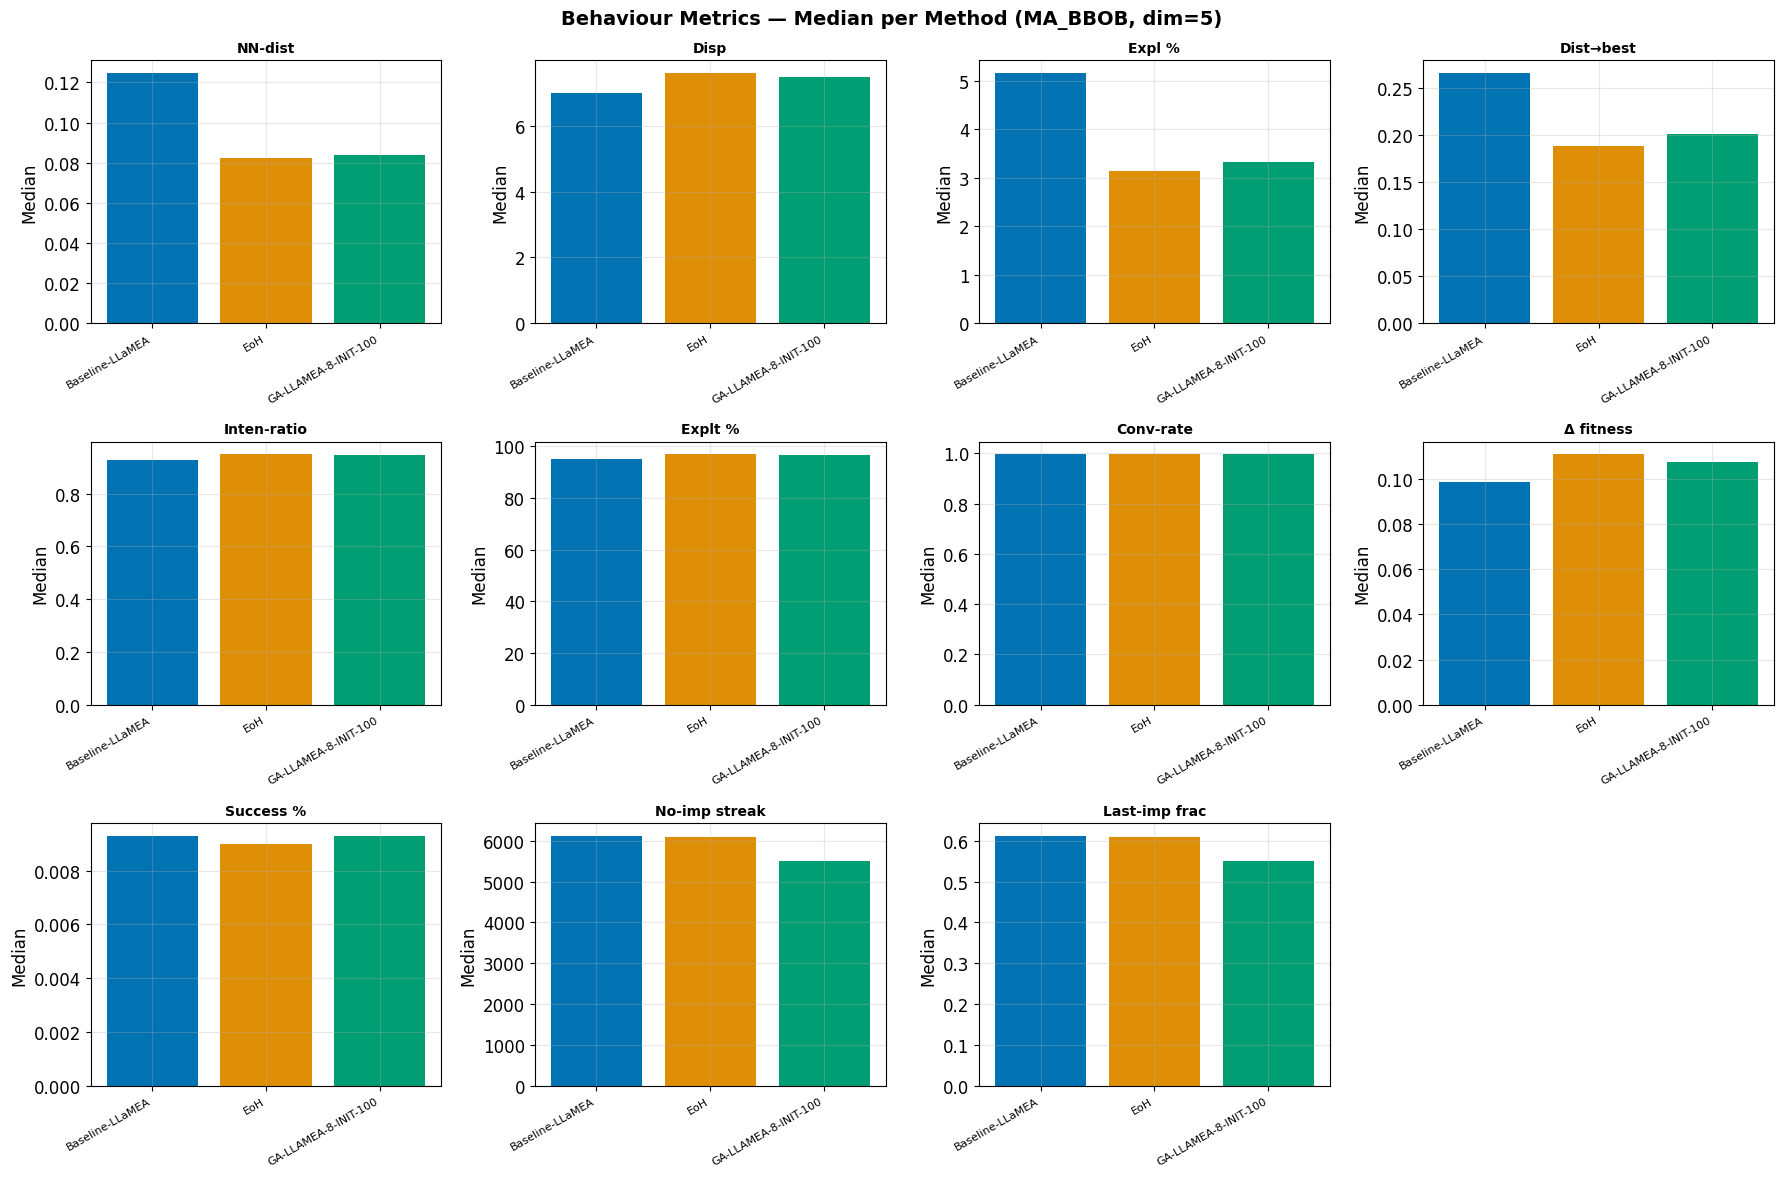

In [ ]:
# Aggregate: median per method
df_agg = (
    df_metrics.groupby('method_name')[BEHAVIOUR_FEATS]
    .median()
    .reset_index()
)

n_feats   = len(BEHAVIOUR_FEATS)
n_methods = len(df_agg)
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

palette = sns.color_palette('colorblind', n_methods)

for i, feat in enumerate(BEHAVIOUR_FEATS):
    ax = axes[i]
    vals = df_agg[feat].values
    ax.bar(df_agg['method_name'], vals, color=palette)
    ax.set_title(NICE_NAMES.get(feat, feat), fontsize=10, fontweight='bold')
    ax.set_xticks(range(n_methods))
    ax.set_xticklabels(df_agg['method_name'], rotation=30, ha='right', fontsize=8)
    ax.set_ylabel('Median')

for j in range(n_feats, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Behaviour Metrics â€” Median per Method (MA_BBOB, dim=5)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6b. Parallel Coordinates â€” Behaviour Profile

In [ ]:
# Min-max scale features so all axes are 0-1
pc = df_metrics[BEHAVIOUR_FEATS + ["method_name"]].dropna().copy()

for feat in BEHAVIOUR_FEATS:
    col_min, col_max = pc[feat].min(), pc[feat].max()
    if col_max > col_min:
        pc[feat] = (pc[feat] - col_min) / (col_max - col_min)
    else:
        pc[feat] = 0.0

pc_renamed = pc.rename(columns=NICE_NAMES)
method_col = "method_name"

# Explicit per-framework colours (colorblind-safe)
FRAMEWORK_COLORS = {
    "EoH":                     "#E69F00",   # amber
    "baseline-LLAMEA":          "#56B4E9",   # sky blue
    "GA-LLAMEA-8-INIT-100":     "#009E73",   # teal green
}
# Fallback for any unexpected method name
fallback = ["#CC79A7", "#F0E442", "#0072B2", "#D55E00"]
color_map = {}
fi = 0
for m in sorted(methods):
    color_map[m] = FRAMEWORK_COLORS.get(m, fallback[fi % len(fallback)])
    if m not in FRAMEWORK_COLORS:
        fi += 1

fig, ax = plt.subplots(figsize=(16, 8))
parallel_coordinates(
    pc_renamed, method_col,
    ax=ax, alpha=0.3, linewidth=0.8,
    color=[color_map[m] for m in pc[method_col]],
)
ax.set_title("Behaviour Profile — Parallel Coordinates (scaled 0-1)", fontsize=14, fontweight="bold")
ax.set_ylabel("Scaled feature value")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'df_metrics' is not defined

### 6c. Correlation Heatmap

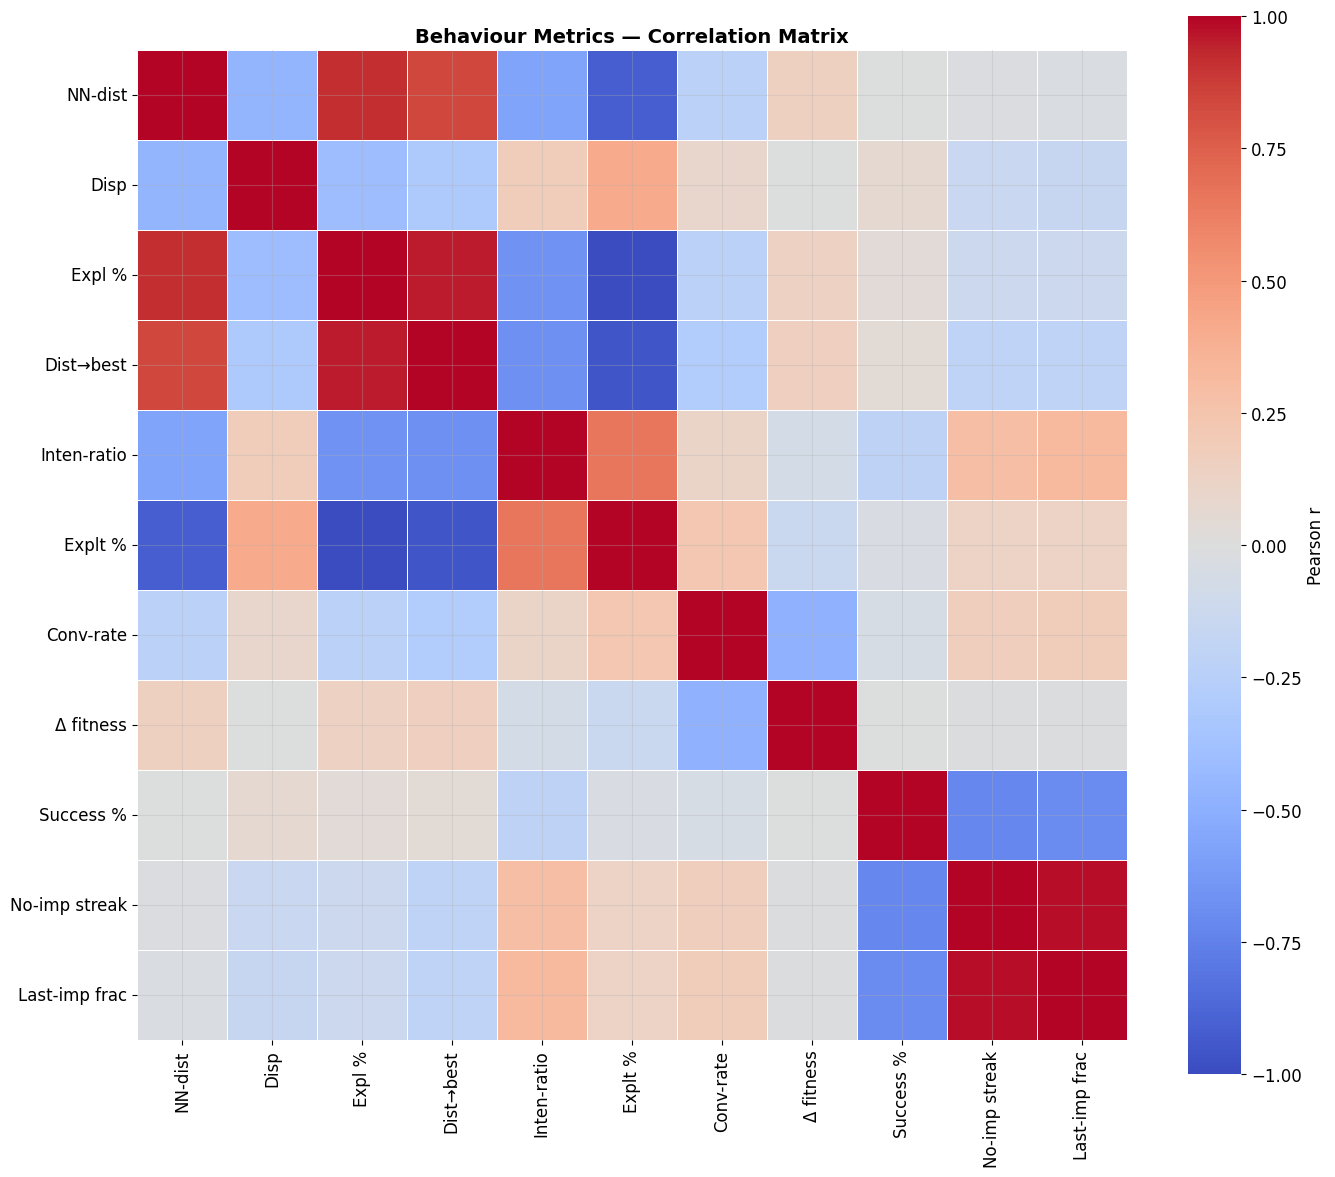

In [ ]:
corr = df_metrics[BEHAVIOUR_FEATS].corr()
corr_renamed = corr.rename(columns=NICE_NAMES, index=NICE_NAMES)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_renamed,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws=dict(label='Pearson r'),
    ax=ax,
)
ax.set_title('Behaviour Metrics â€” Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6d. Exploration vs Exploitation per Method (Violin)

C:\Users\Kukoy\AppData\Local\Temp\ipykernel_29032\3318646105.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\Kukoy\AppData\Local\Temp\ipykernel_29032\3318646105.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


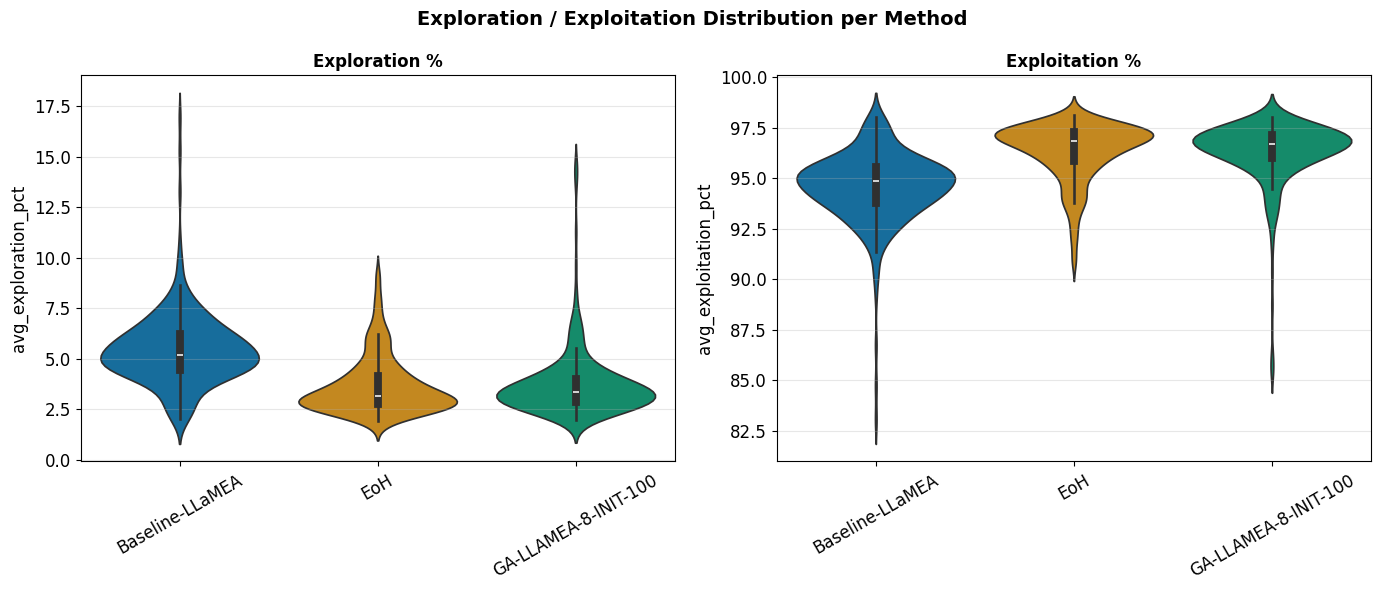

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, feat, title in zip(
    axes,
    ['avg_exploration_pct', 'avg_exploitation_pct'],
    ['Exploration %', 'Exploitation %'],
):
    sns.violinplot(
        data=df_metrics, x='method_name', y=feat,
        palette='colorblind', inner='box', ax=ax,
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Exploration / Exploitation Distribution per Method', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6e. No-Improvement Streak & Success Rate

C:\Users\Kukoy\AppData\Local\Temp\ipykernel_29032\924348577.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Kukoy\AppData\Local\Temp\ipykernel_29032\924348577.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


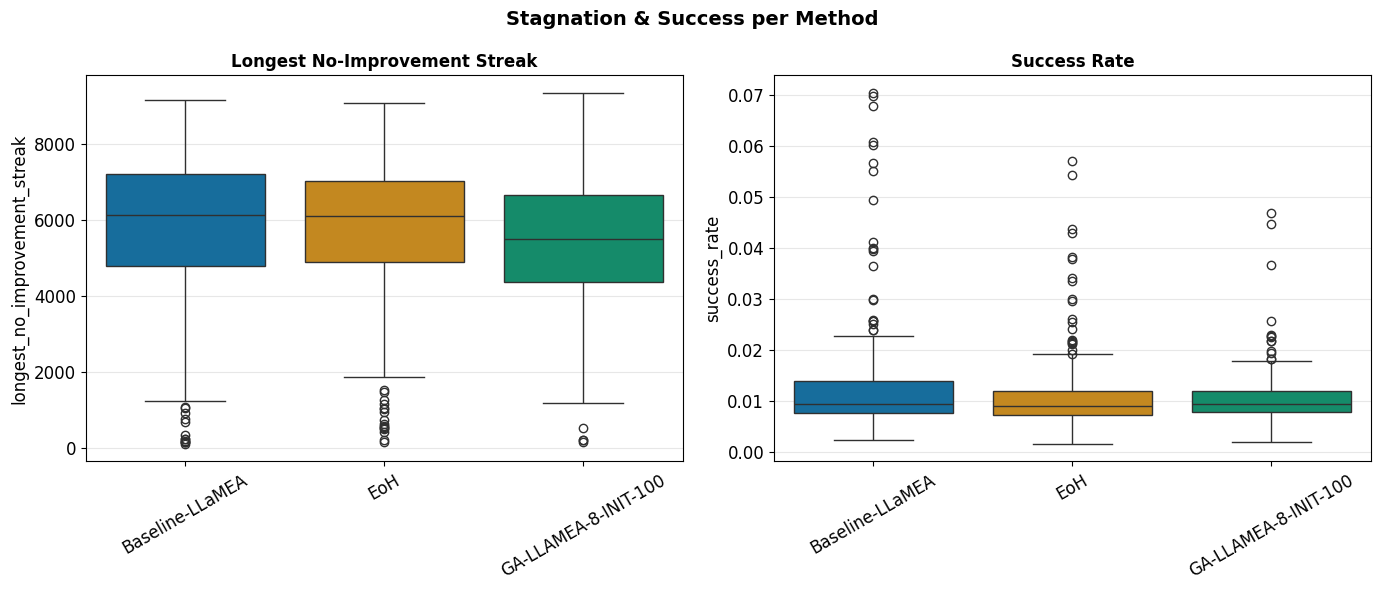

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, feat, title in zip(
    axes,
    ['longest_no_improvement_streak', 'success_rate'],
    ['Longest No-Improvement Streak', 'Success Rate'],
):
    sns.boxplot(
        data=df_metrics, x='method_name', y=feat,
        palette='colorblind', ax=ax,
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Stagnation & Success per Method', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Elo Rating (Tournament Ranking)

Simulates 100â€¯000 rounds of pairwise tournament matches using the full IOH run data.
A higher Elo rating means the algorithm consistently outperforms its opponents.

In [ ]:
# Reload monotonic data (needed for tournament ranking)
manager_elo = iohinspector.DataManager()
for method in sorted(methods):
    d = os.path.join(IOH_OUTPUT_DIR, method)
    if os.path.isdir(d):
        manager_elo.add_folder(d)

df_elo_input = manager_elo.load(monotonic=True, include_meta_data=True)
print(f'Loaded {len(df_elo_input)} rows for Elo computation')
print(f'Algorithms: {df_elo_input["algorithm_name"].unique().to_list()}')

Loaded 85473 rows for Elo computation
Algorithms: ['GA-LLAMEA-8-INIT-100', 'Baseline-LLaMEA', 'EoH']


In [ ]:
dt_elo = iohinspector.get_tournament_ratings(df_elo_input, nrounds=100000)
dt_elo['Rating']    = pd.to_numeric(dt_elo['Rating'],    errors='coerce')
dt_elo['Deviation'] = pd.to_numeric(dt_elo['Deviation'], errors='coerce').fillna(0)

print('Elo Ratings (sorted, best first):')
print(dt_elo.sort_values('Rating', ascending=False).to_string(index=False))

Elo Ratings (sorted, best first):
     Rating  Deviation       algorithm_name
1554.518599  36.160218 GA-LLAMEA-8-INIT-100
1511.348657  34.832730                  EoH
1434.132744  34.684655      Baseline-LLaMEA


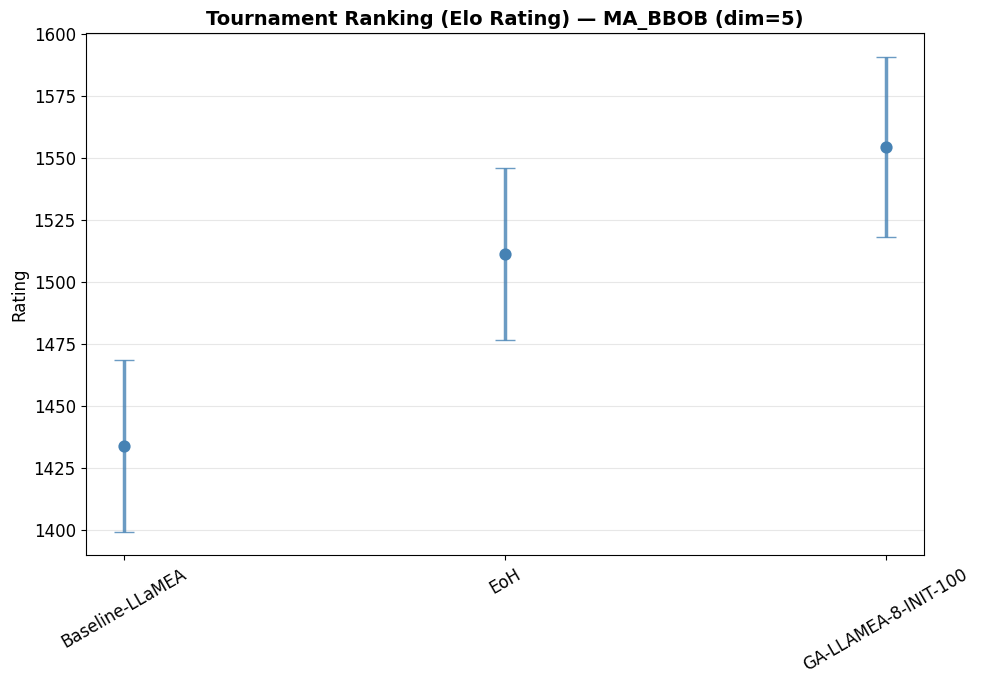

In [ ]:
dt_elo_sorted = dt_elo.sort_values('algorithm_name').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 7))
sns.pointplot(
    data=dt_elo_sorted, x='algorithm_name', y='Rating',
    linestyle='none', ax=ax, color='steelblue',
)
ax.errorbar(
    dt_elo_sorted['algorithm_name'],
    dt_elo_sorted['Rating'],
    yerr=dt_elo_sorted['Deviation'],
    fmt='o', color='steelblue', alpha=0.8, capsize=7, elinewidth=2.5,
)
ax.tick_params(axis='x', rotation=30)
ax.set_xlabel('')
ax.set_title('Tournament Ranking (Elo Rating) â€” MA_BBOB (dim=5)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

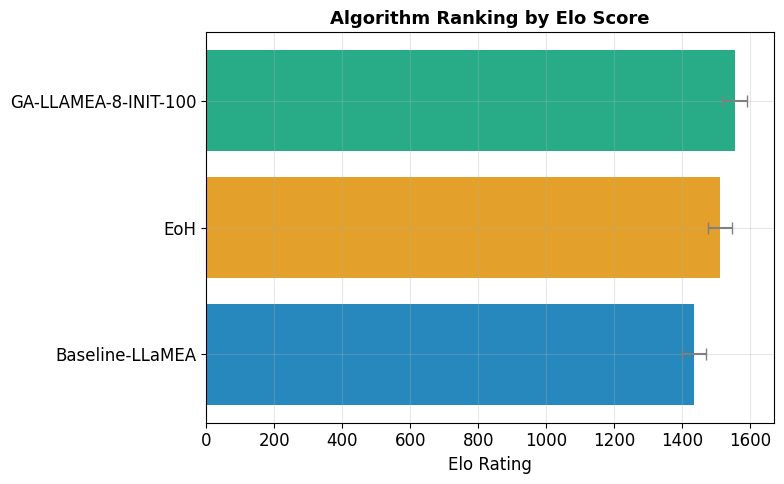

In [ ]:
# Bar chart version â€” sorted by rating
dt_elo_ranked = dt_elo.sort_values('Rating', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = sns.color_palette('colorblind', len(dt_elo_ranked))
ax.barh(
    dt_elo_ranked['algorithm_name'],
    dt_elo_ranked['Rating'],
    xerr=dt_elo_ranked['Deviation'],
    color=colors, alpha=0.85, capsize=4, ecolor='gray',
)
ax.set_xlabel('Elo Rating')
ax.set_title('Algorithm Ranking by Elo Score', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Summary Table

In [ ]:
# Combine AOCC + Elo into one summary
# FIX: aocc is already a pandas DataFrame (get_aocc has return_as_pandas=True by default)
aocc_pd = aocc.rename(columns={'algorithm_name': 'Method', 'AOCC': 'AOCC (median)'})
elo_pd  = dt_elo.rename(columns={'algorithm_name': 'Method'})[['Method', 'Rating', 'Deviation']]
elo_pd.columns = ['Method', 'Elo Rating', 'Elo Deviation']

summary = aocc_pd.merge(elo_pd, on='Method', how='outer').sort_values('Elo Rating', ascending=False)
summary[['AOCC (median)', 'Elo Rating', 'Elo Deviation']] = summary[
    ['AOCC (median)', 'Elo Rating', 'Elo Deviation']
].round(4)
print('Summary â€” AOCC & Elo Ratings:')
print(summary.to_string(index=False))

Summary â€” AOCC & Elo Ratings:
              Method  AOCC (median)  Elo Rating  Elo Deviation
GA-LLAMEA-8-INIT-100         0.8157   1554.5186        36.1602
                 EoH         0.8234   1511.3487        34.8327
     Baseline-LLaMEA         0.7921   1434.1327        34.6847
